In [1]:
import torch
import torch.nn as nn
from multigrid import DirichletBoundaryCondition, NeumannBoundaryCondition, laplace_jacobi_step, laplace_jacobi_smoothen, poisson_jacobi_smoothen
from multigrid import laplace_multigrid_v_cycle, laplace_multigrid_w_cycle, laplace_multigrid_f_cycle, laplace_full_multigrid_v_cycle, laplace_multigrid_half_v_cycle
from multigrid import poisson_exact_solve, poisson_multigrid, integrate_vf_on_grid
from utils import interpolate, restrict2d, laplace_smoothen, restrict1d, even_pad
import time
import matplotlib.pyplot as plt

## Updated Laplace interface

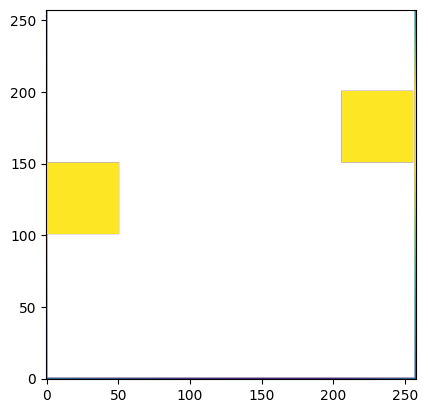

In [14]:
n = 256
bc = DirichletBoundaryCondition.empty_w_size(n, n)

bc.bottom[:128] = torch.linspace(13, 5, 128)
bc.bottom[128:192] = 5
bc.bottom[192:] = torch.linspace(5, 13, 64)

bc.top = 21

bc.left[:100] = torch.linspace(13, 40, 100)
bc.left[100:150] = 40
bc.left[150:] = torch.linspace(40, 21, 106)

bc.right[:150] = torch.linspace(13, 40, 150)
bc.right[150:200] = 40
bc.right[200:] = torch.linspace(40, 21, 56)

bc.add_rectangle(50, 50, 40, left=0, bottom=100)
bc.add_rectangle(50, 50, 40, right=-1, top=200)

bc.show()

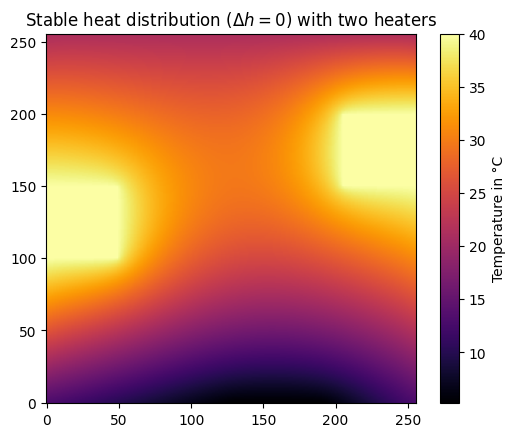

In [16]:
f_smooth = laplace_multigrid_half_v_cycle(torch.full((256, 256), 22.), bc, depth=4, tol=1e-4, maxiter=200, jacobi_damping_factor=2/3)
plt.imshow(f_smooth, cmap='inferno', origin='lower')
plt.colorbar(label='Temperature in °C')
plt.title('Stable heat distribution ($\\Delta h = 0$) with two heaters')
plt.show()

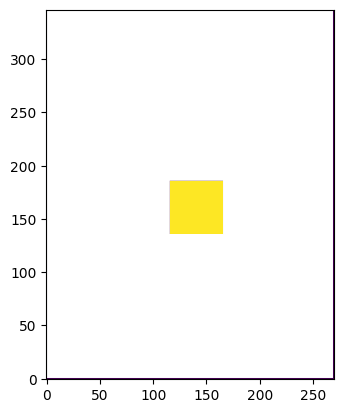

In [11]:
bc = DirichletBoundaryCondition.empty_w_size(345, 268)
bc.left = bc.right = bc.top = bc.bottom = 0
bc.add_rectangle(50, 50, 10, center=(140, 160))
bc.show()

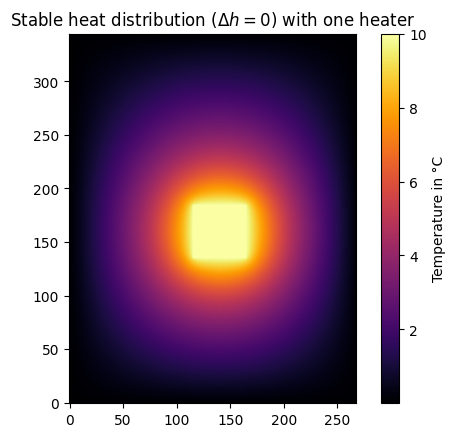

In [13]:
f_smooth = laplace_multigrid_half_v_cycle(torch.full((345, 268), 5.), bc, depth=4, tol=1e-4, maxiter=200, jacobi_damping_factor=1.)
plt.imshow(f_smooth, cmap='inferno', origin='lower')
plt.colorbar(label='Temperature in °C')
plt.title('Stable heat distribution ($\\Delta h = 0$) with one heater')
plt.show()